In [8]:
import pandas as pd
import numpy as np


In [9]:
import mcf


ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.3.

In [5]:
from mcf.mcf_main import ModifiedCausalForest


In [223]:
df_aggregate = pd.read_excel('/Users/ghadaelhusseini/Documents/Kassel University Masters /Thesis/Replication/Lechner(2018)_Data/Data120190214.xlsx')

In [192]:

# assuming your main dataset is called "data"
toy_data = df_aggregate.sample(frac=2/3, random_state=42)  # random_state for reproducibility

print(toy_data.shape)


(40081, 929)


In [224]:
columns_to_keep = [
    "case_id", "ADM2ID", "country_num", "year", "CONFLICT_YES", "CONFLICT_YES_P1",
    "mean_light", "MEAN_LIGHT_LOG1", "sum_light", "SUM_RESSOURCES", "PX", "PX_LOWVALW",
    "HIGHVALW", "PX_DISC_2", "PX_DISC_3", "PX_DISC_4", "PX_DISC_5", "mine_count",
    "area", "tri", "tri_norm", "min_elev", "max_elev", "mean_elev", "median_elev",
    "distance_to_capital", "frac_LU_artificial", "frac_LU_cropland", "frac_LU_grass",
    "frac_LU_tree", "frac_LU_shrubs", "frac_LU_herbaceous", "frac_LU_mangroves",
    "frac_LU_sparse", "frac_LU_baresoil", "frac_LU_snow", "frac_LU_water",
    "temperature_mean", "precipitation_mean", "AgriSuit_mean", "AgriSuit_median",
    "ETH_ethnologue_groups", "ETH_Murdock_groups", "pre_col_polity", "ports",
    "port_oil_terminal", "pop", "pop_density", "icrg_qog", "p_xconst", "wbgi_cce",
    "wbgi_gee", "wbgi_pve", "wbgi_rle", "wbgi_rqe", "wbgi_vae", "p_polity2",
    "iaep_ufs", "wdi_gdpcapcon2010", "wdi_gdpcapgr", "wdi_inflation",
    "fh_pr", "fh_cl", "ethfrac",
    "Ag_prod_", "Au_prod_", "Bx_prod_", "Ch_prod_", "Co_prod_", "Coal_prod_",
    "Cu_prod_", "Diam_prod_", "Fe_prod_", "Gph_prod_", "Lanth_prod_", "Li_prod_",
    "Mg_prod_", "Ni_prod_", "Pb_prod_", "Pd_prod_", "Phos_prod_", "Pot_prod_",
    "Pt_prod_", "Rut_prod_", "Sc_prod_", "Sn_prod_", "Sv_prod_", "Ta_prod_",
    "U3O8_prod_", "V_prod_", "W_prod_", "Zn_prod_", "Zr_prod_",
    "price_Coal", "price_Phos", "price_Fe", "price_Pb", "price_Ni", "price_Ag",
    "price_Pot", "price_Ilm", "price_Rut", "price_Zr", "price_Ch", "price_Sv",
    "price_Lanth", "price_Li", "price_Gph", "price_Bx", "price_Mg", "price_W",
    "price_Co", "price_Ta", "price_V", "price_Diam", "price_U3O8", "price_Au",
    "price_Pd", "price_Pt", "price_Cu", "price_Sn", "price_Zn", "price_Al",
    "mean_travel_time", "max_travel_time", "vdem_corr", "UCDP_event", "battle",
    "headquarters", "nonviolent", "remoteviol", "riot", "strategic_dev", "violence_civ",
    "ACLED_death", "Power_Plants", "Power_Plant_Hydro", "Power_Plant_Thermal",
    "Power_Plant_OTHER", "ht_colonial"
]

In [225]:
df = df_aggregate[[col for col in columns_to_keep if col in df_aggregate.columns]]


In [226]:
print(df.head())

   case_id  ADM2ID  country_num  year  CONFLICT_YES  CONFLICT_YES_P1  \
0    33094     329            2  1997             0                1   
1    33095     329            2  1998             1                1   
2    33096     329            2  1999             1                0   
3    33097     329            2  2000             0                1   
4    33098     329            2  2001             1                0   

   mean_light  MEAN_LIGHT_LOG1  sum_light  SUM_RESSOURCES  ...  remoteviol  \
0         0.0              0.0          0               0  ...           0   
1         0.0              0.0          0               0  ...           0   
2         0.0              0.0          0               0  ...           0   
3         0.0              0.0          0               0  ...           0   
4         0.0              0.0          0               0  ...           0   

   riot  strategic_dev  violence_civ  ACLED_death  Power_Plants  \
0     0              0         

In [8]:

# Specify the folder path (change this to your folder)
folder_path = '/Users/ghadaelhusseini/Documents/Kassel University Masters /Thesis/my_Data'

# Save to Excel in that folder
df.to_excel(folder_path + "Filtered_df.xlsx", index=False)

print("Excel file saved successfully in:", folder_path)



Excel file saved successfully in: /Users/ghadaelhusseini/Documents/Kassel University Masters /Thesis/my_Data


In [7]:
print("Rows:", len(df))
print("Columns available:", df.columns.tolist()[:50])

NameError: name 'df' is not defined

In [228]:
outcome= "CONFLICT_YES"

In [229]:
# -----------------------------
# STEP 1: Start with everyone as control (non-mining districts)
# -----------------------------
df["treat"] = 0

# -----------------------------
# STEP 2: Assign treatment bins to mining districts
# -----------------------------
# For districts with at least one mine, assign treatment value from PX_DISC_3
df.loc[df["mine_count"] > 0, "treat"] = df.loc[df["mine_count"] > 0, "PX_DISC_3"]

# -----------------------------
# Convert to integer type
df["treat"] = df["treat"].astype(int)

# -----------------------------
# STEP 4: Check the result
# -----------------------------
print("Unique treatment categories:", sorted(df["treat"].unique()))
print("\nTreatment group counts:")
print(df["treat"].value_counts().sort_index())


Unique treatment categories: [np.int64(0), np.int64(1), np.int64(2)]

Treatment group counts:
treat
0    58271
1      867
2      983
Name: count, dtype: int64


/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_83534/1821980929.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["treat"] = 0
/var/folders/4f/qxlwg6z95tgd3by8tpxwc6kh0000gn/T/ipykernel_83534/1821980929.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["treat"] = df["treat"].astype(int)


In [230]:
print(df["treat"].describe())
print(df["treat"].value_counts().sort_index())


count    60121.000000
mean         0.047122
std          0.278574
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: treat, dtype: float64
treat
0    58271
1      867
2      983
Name: count, dtype: int64


In [231]:
x_ord = [

    "area",                    # Area (km2)
    "tri",                     # Ruggedness
    "min_elev",                # Elevation (min)
    "max_elev",                # Elevation (max)
    "median_elev",             # Elevation (median)
    "distance_to_capital",     # Distance to Capital (meters)
    "frac_LU_artificial",      # Land Use - Artificial
    "frac_LU_cropland",        # Land Use - Cropland
    "frac_LU_grass",           # Land Use - Grass
    "frac_LU_tree",            # Land Use - Trees
    "frac_LU_shrubs",          # Land Use - Shrubs
    "frac_LU_herbaceous",      # Land Use - Herbaceous
    "frac_LU_mangroves",       # Land Use - Mangroves
    "frac_LU_sparse",          # Land Use - Sparse
    "frac_LU_baresoil",        # Land Use - Baresoil
    "frac_LU_snow",            # Land Use - Snow
    "frac_LU_water",           # Land Use - Water
    "temperature_mean",        # Temperature (mean, deg. Celsius)
    "precipitation_mean",      # Precipitation (mm)
    "AgriSuit_mean",           # Agricultural Suitability
    "ETH_ethnologue_groups",   # Ethnic Groups (Ethnologue)
    "ETH_Murdock_groups",      # Ethnic Groups (Murdock)
    "pre_col_polity",          # Pre-Colonial Polity
    "ports",                   # Ports
    "port_oil_terminal",       # Ports - Oil Terminal
    "pop",                     # Population
    "pop_density",             # Population Density
    "icrg_qog",                # ICRG Quality of Government
    "p_xconst",                # Executive Constraints
    "wbgi_cce",                # WGI Control of Corruption
    "wbgi_gee",                # WGI Government Effectiveness
    "wbgi_pve",                # WGI Political Stability
    "wbgi_rle",                # WGI Rule of Law
    "wbgi_rqe",                # WGI Regulatory Quality
    "wbgi_vae",                # WGI Voice and Accountability
    "p_polity2",               # Polity2
    "wdi_gdpcapcon2010",       # GDP p.c. (2010, PPP)
    "fh_pr",                   # Freedom House Political Rights
    "fh_cl",                   # Freedom House Civil Liberties
    #"relfrac"                  # Religious Fractionalisation
]


In [232]:
x_unord = [
    "ht_colonial"
]

In [162]:
help(ModifiedCausalForest)


Help on class ModifiedCausalForest in module mcf.mcf_main:

class ModifiedCausalForest(builtins.object)
 |  ModifiedCausalForest(var_d_name=None, var_id_name=None, var_iv_name=None, var_w_name=None, var_x_name_always_in_ord=None, var_x_name_always_in_unord=None, var_x_name_balance_test_ord=None, var_x_name_balance_test_unord=None, var_x_name_remain_ord=None, var_x_name_remain_unord=None, var_x_name_ord=None, var_x_name_unord=None, var_y_name=None, var_y_tree_name=None, var_z_name_cont=None, var_z_name_ord=None, var_z_name_unord=None, cf_alpha_reg_grid=1, cf_alpha_reg_max=0.15, cf_alpha_reg_min=0.05, cf_boot=1000, cf_chunks_maxsize=None, cf_compare_only_to_zero=False, cf_n_min_grid=1, cf_n_min_max=None, cf_n_min_min=None, cf_n_min_treat=None, cf_nn_main_diag_only=False, cf_m_grid=1, cf_m_random_poisson=True, cf_m_share_max=0.6, cf_m_share_min=0.1, cf_match_nn_prog_score=True, cf_mce_vart=1, cf_random_thresholds=None, cf_p_diff_penalty=None, cf_penalty_type='mse_d', cf_subsample_factor_e

In [233]:
my_mcf = ModifiedCausalForest(
    var_y_name=outcome,  # Outcome variable
    var_d_name="treat",    # Treatment variable
    var_x_name_ord=x_ord,  # Ordered covariates
    var_x_name_unord=x_unord,  # Unordered covariate
  #  _int_show_plots=False,
    cs_detect_const_vars_stop=False,
    #cs_max_del_train= 0.55,
    cf_boot=200,
    _int_seed_sample_split=67567885,
    var_x_name_balance_bgate= ['p_xconst', 'icrg_qog']# common support threshold
)

Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output0 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output1 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output2 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output3 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output4 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output5 already exists A new directory is created for the output.
Directory for output /Users/ghadaelhusseini/PyCharmMiscProject/output6 already exists A new direct

In [234]:
x_ord = [v for v in x_ord if v not in ["frac_LU_snow"]]
x_unord = [v for v in x_unord if v not in ["port_oil_terminal_prime"]]


In [235]:
from sklearn.model_selection import train_test_split


In [236]:
training_df, prediction_df = train_test_split(df, test_size=0.5, random_state=42)


Modified Causal Forest: Training 
----------------------------------------------------------------------------------------------------

int_dict 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
iv :   False
cuda :   False
cython :   False
del_forest :   False
keep_w0 :   False
descriptive_stats :   True
dpi :   500
fontsize :   x-small
all_fonts :   xx-small x-small small medium large x-large xx-large
legend_loc :   best
no_filled_plot :   20
mp_ray_del :   refs
mp_ray_objstore_multiplier :   1
no_ray_in_forest_building :   False
mp_weights_tree_batch :   0
share_forest_sample :   0.5
weight_as_sparse :   True
show_plots :   True
report :   True
with_output :   True
verbose :   True
max_save_values :   50
mp_weights_type :   1
return_iate_sp :   True
seed_sample_split :   67567885
smaller_sample :   None
weight_as_sparse_splits :   None
mp_ray_shutdown :   False
mp_vim_type :   2
max_cats_cont_vars :   100030060
output_no_new_dir :  

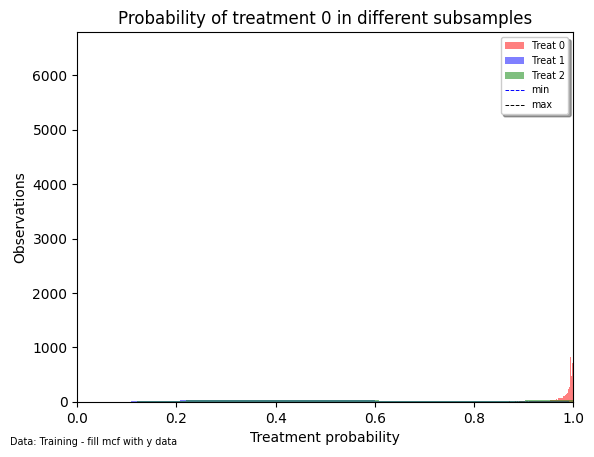

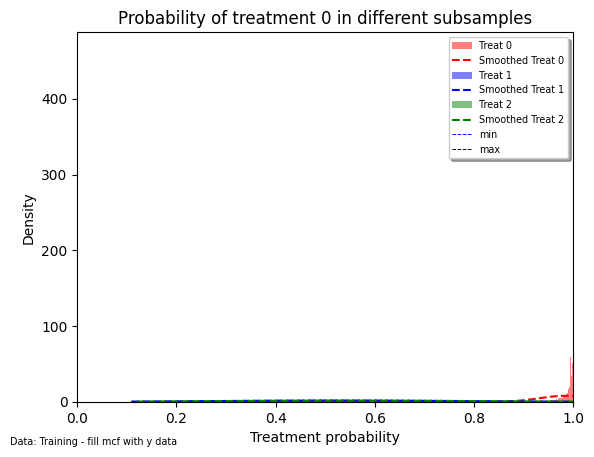

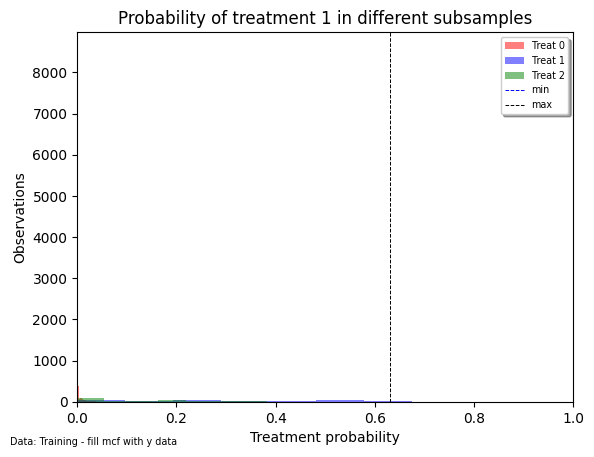

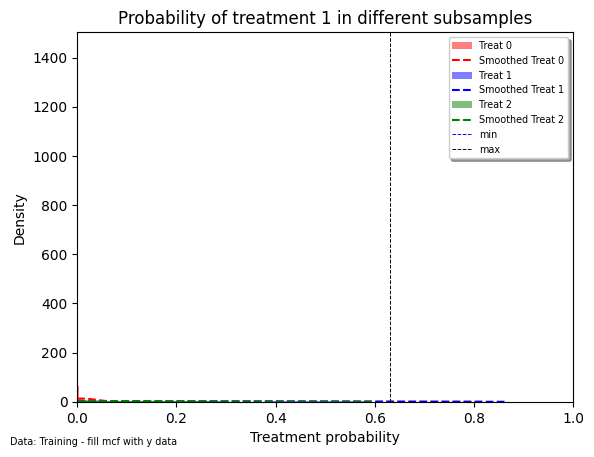

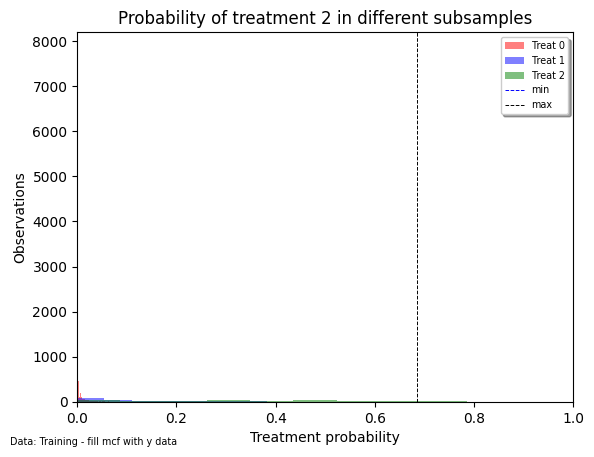

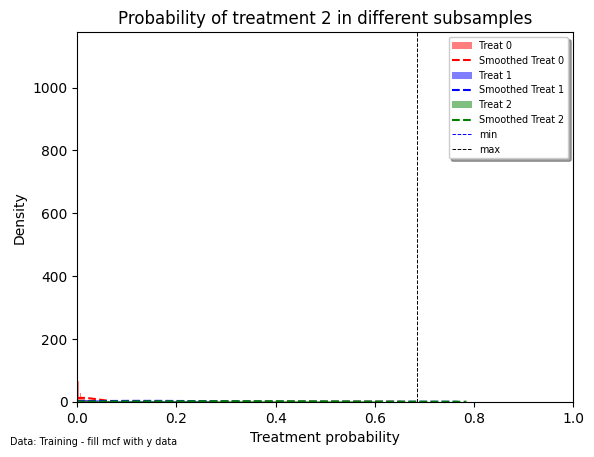


----------------------------------------------------------------------------------------------------
Data investigated for common support: Training - fill mcf with y data
----------------------------------------------------------------------------------------------------
Observations deleted:   40 (0.27%)
----------------------------------------------------------------------------------------------------

Observations kept, by treatment
            Obs.  Share in %
treat                   
0      14564       97.16
1        185        1.23
2        241        1.61
-   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   -   
Observations deleted, by treatment
        Obs.  Share in %
treat                  
0         2         5.0
1        27        67.5
2        11        27.5

----------------------------------------------------------------------------------------------------
Full sample (Data ON and OFF support)
----------------------------------------------------

{'tree_df':        id_mcf  conflict_yes  treat         area         tri  min_elev  \
 0        3549             0      1    715.16583  100.850000      1559   
 1        1766             0      0    831.09595    9.459000         1   
 2        7150             0      0    180.87325    1.111330        52   
 3       20525             0      0    835.63666   26.284700       330   
 4        4962             0      0    377.69403   12.375500       143   
 ...       ...           ...    ...          ...         ...       ...   
 14993   29802             0      1   2080.12940   32.030701      1512   
 14994    5390             0      0   4822.24220   21.046499      1167   
 14995     860             0      0  15372.82400   33.578602      1053   
 14996   15795             0      0   1765.98510    5.444340        73   
 14997   23654             0      0    273.23026    2.382210       156   
 
        max_elev  median_elev  distance_to_capital  frac_lu_artificial  ...  \
 0          2622    

In [237]:
my_mcf.train(training_df)


In [ ]:
results = my_mcf.predict(prediction_df)


Modified Causal Forest: Prediction 
----------------------------------------------------------------------------------------------------

int_dict 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
iv :   False
cuda :   False
cython :   False
del_forest :   False
keep_w0 :   False
descriptive_stats :   True
dpi :   500
fontsize :   x-small
all_fonts :   xx-small x-small small medium large x-large xx-large
legend_loc :   best
no_filled_plot :   20
mp_ray_del :   refs
mp_ray_objstore_multiplier :   1
no_ray_in_forest_building :   False
mp_weights_tree_batch :   0
share_forest_sample :   0.5
weight_as_sparse :   True
show_plots :   True
report :   True
with_output :   True
verbose :   True
max_save_values :   50
mp_weights_type :   1
return_iate_sp :   True
seed_sample_split :   67567885
smaller_sample :   None
weight_as_sparse_splits :   None
mp_ray_shutdown :   False
mp_vim_type :   2
max_cats_cont_vars :   100030060
output_no_new_dir :

In [206]:
ate_array = results.get('ate')
print("Average Treatment Effect (ATE):\n", ate_array)

Average Treatment Effect (ATE):
 [[[-0.0046601   0.02663418  0.03129428]]]


In [83]:
import mcf.mcf_gate_functions as gate

In [ ]:
gate_array = results.get('gate')
print("Group Average Treatment Effect (GATE):\n", gate_array)

In [82]:
for column in df.columns:
    print(f"Descriptive statistics for {column}:")
    print(df[column].describe())  # gives count, mean, std, min, 25%, 50%, 75%, max
    print("\n")

Descriptive statistics for case_id:
count     20040.000000
mean      80049.715319
std       27806.833149
min       33095.000000
25%       56774.250000
50%       80964.500000
75%      102047.000000
max      130760.000000
Name: case_id, dtype: float64


Descriptive statistics for ADM2ID:
count    20040.000000
mean     21684.697555
std      11725.343469
min        329.000000
25%      13868.000000
50%      23607.000000
75%      31135.000000
max      51725.000000
Name: ADM2ID, dtype: float64


Descriptive statistics for country_num:
count    20040.000000
mean        29.192465
std         15.410216
min          2.000000
25%         18.000000
50%         35.000000
75%         39.000000
max         53.000000
Name: country_num, dtype: float64


Descriptive statistics for year:
count    20040.000000
mean      2004.179591
std          4.900775
min       1996.000000
25%       2000.000000
50%       2004.000000
75%       2008.000000
max       2012.000000
Name: year, dtype: float64


Descriptive stat

In [ ]:
from mcf import ModifiedCausalForest
help(ModifiedCausalForest)
